# Solving the Steady-State Radiative Transfer Equation (RTE/RFE) using Hard-PINNs

In this notebook, we solve the steady-state 1D Radiative Transfer Equation (RTE) using a **Hard-PINN** approach.
Boundary conditions are enforced exactly by construction using indicator functions.


### Case 1 (1D) 
We first focus on a simple case , which is a 1D space + 1D direction test case with the following configuration :
* **Geometry:** $0 \le x \le L_x$ with $L_x = 1.0\text{ m}$.
* **Equation (1D RTE):**
  $$\mu \frac{\partial I}{\partial x} + (\kappa + \sigma(x)) I(x, \mu) = \frac{\sigma(x)}{2} \int_{-1}^{1} I(x, \mu') d\mu'$$
* **Physical Properties:**
  * Absorption coefficient: $\kappa = 0$ (Non-absorbing medium).
  * Scattering coefficient: $\sigma(x) = \frac{1}{x}$.
* **Boundary Conditions (BC):**
  * At $x = 0$ (for incoming directions $\mu > 0$): $I(0, \mu) = 1$
  * At $x = L_x = 1$ (for incoming directions $\mu < 0$): $I(1, \mu) = 0$


### Hard-PINN Formulation (Hard Constraints)

To exactly enforce the boundary conditions (BC) without adding any boundary penalty to the loss function, we formulate the parameterized solution as:

$$I(x, \mu) = A(x, \mu) + B(x, \mu) \cdot N(x, \mu)$$

Where $N(x, \mu)$ is the raw neural network output, and $A(x, \mu)$ and $B(x, \mu)$ are analytical functions defined using indicator functions $\mathbb{1}$ based on the propagation direction $\mu$:

* **Function $A(x, \mu)$** (enforces the target boundary value):
  $$A(x, \mu) = 1.0 \cdot \mathbb{1}_{\mu > 0} + 0.0 \cdot \mathbb{1}_{\mu \le 0} = \mathbb{1}_{\mu > 0}$$

* **Function $B(x, \mu)$** (selectively vanishes at the incoming boundaries):
  $$B(x, \mu) = x \cdot \mathbb{1}_{\mu > 0} + (1 - x) \cdot \mathbb{1}_{\mu \le 0}$$


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

## 1. PINN Architecture Definition
Definition of the standard Neural Network (Multi-Layer Perceptron) to approximate the solution $u(t,x)$.

In [2]:
class HardPinnRFEEq(nn.Module):
    def __init__(self):
        super().__init__()
        self.couche_entree = nn.Linear(2, 50)
        self.couche_cachee1 = nn.Linear(50, 50)
        self.couche_cachee2 = nn.Linear(50, 50)
        self.couche_sortie = nn.Linear(50, 1)

    def forward(self, inputs):
        x = inputs[:, 0:1]
        mu = inputs[:, 1:2]

        h = torch.tanh(self.couche_entree(inputs))
        h = torch.tanh(self.couche_cachee1(h))
        h = torch.tanh(self.couche_cachee2(h))
        N_pred = self.couche_sortie(h)

        A = torch.where(mu > 0, torch.ones_like(x), torch.zeros_like(x))
        B = torch.where(mu > 0, x, 1.0 - x)

        return A + B * N_pred


## 2. Sampling and Collocation Points Generation
Functions to generate collocation points (in the domain) ,and boundary points ($x=0$ and $x=1$).

In [3]:
mu_min, mu_max = -1.0, 1.0
x_min, x_max = 0.0, 1.0


def generer_points_collocation(n_pde):
    mu_colloc = torch.rand(n_pde, 1) * (mu_max - mu_min) + mu_min
    x_colloc = torch.rand(n_pde, 1) * (x_max - x_min) + x_min
    return mu_colloc.float(), x_colloc.float()



def generer_points_bords(n_bords):                                                                       
    n_half = n_bords // 2                                                                                
                                                                                                             
    x_gauche = torch.zeros(n_half, 1)                                                                    
    mu_gauche = torch.rand(n_half, 1)                                                 
                                                                                                             
    x_droite = torch.ones(n_half, 1)                                                                     
    mu_droite = -torch.rand(n_half, 1)                                            
                                                                                                             
    return x_gauche.float(), mu_gauche.float(), x_droite.float(), mu_droite.float()   

## 3. Loss Functions Definition
Grouping of loss calculation functions for initial conditions (IV), boundary conditions (BC), and the PDE residual (CLP).

In [4]:
def calc_clp_loss(model, mu_colloc, x_colloc):
    mu_colloc.requires_grad_(True)
    x_colloc.requires_grad_(True)

    I_pred = model(torch.cat([x_colloc, mu_colloc], dim=1))

    I_x = torch.autograd.grad(
        outputs=I_pred,
        inputs=x_colloc,
        grad_outputs=torch.ones_like(I_pred),
        create_graph=True,
    )[0]

    N = x_colloc.shape[0]
    x_expanded = x_colloc.repeat(1, N_quadrature)
    mu_expanded = quad_mu.t().repeat(N, 1)

    inputs = torch.cat([x_expanded.flatten().view(-1, 1), mu_expanded.flatten().view(-1, 1)], dim=1)
    I_quad_preds = model(inputs).view(N, N_quadrature)

    integral = torch.sum(I_quad_preds * quad_w.t(), dim=1, keepdim=True)
    
    sigma_x = 1.0 / x_colloc   

    pde_residual = mu_colloc * I_x + sigma_x * I_pred - 0.5 * sigma_x * integral
    loss_pde = torch.mean(pde_residual ** 2)

    return loss_pde


## 4. Hardware (Device), Model, and Optimizer Initialization
Hardware detection, model creation, and optimizer definition.

In [5]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

mu_colloc, x_colloc = generer_points_collocation(12000)


mu_colloc, x_colloc = mu_colloc.to(device), x_colloc.to(device)
n_bords = 1000
x_g, mu_g, x_d, mu_d = generer_points_bords(n_bords) 
x_g = x_g.to(device)                                                                                     
mu_g = mu_g.to(device)                                                                                   
x_d = x_d.to(device)                                                                                     
mu_d = mu_d.to(device)                                                                                   
                                                                                                             

mps


In [6]:
N_quadrature = 16
nodes, weights = np.polynomial.legendre.leggauss(N_quadrature)                                                    
                                                                                                             
quad_mu = torch.tensor(nodes, dtype=torch.float32).view(N_quadrature, 1).to(device)                     
quad_w = torch.tensor(weights, dtype=torch.float32).view(N_quadrature, 1).to(device)


## 5. Model Training
Training phase of the PINN model using the defined optimizers (Adam and/or L-BFGS).

In [7]:
modele = HardPinnRFEEq().to(device)
optimizer = optim.Adam(modele.parameters(), lr=0.001, weight_decay=1e-5)

epochs = 2000

for epoch in range(epochs):
    optimizer.zero_grad()
    loss_clp = calc_clp_loss(modele, mu_colloc, x_colloc)
    loss_totale = loss_clp
    loss_totale.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoque {epoch:05d} | "
              f"Loss totale (CLP): {loss_totale.item():.2e}"
              )

def closure():
    optimizer.zero_grad()
    loss_clp = calc_clp_loss(modele, mu_colloc, x_colloc)
    loss_totale = loss_clp
    loss_totale.backward()
    return loss_totale

lbfgs_epochs = 500
optimizer = optim.LBFGS(modele.parameters(), line_search_fn="strong_wolfe", max_iter=20)
for epoch in range(lbfgs_epochs):
    loss = optimizer.step(closure)
    if epoch % 100 == 0:
        print(f"Epoque LBFGS {epoch:05d} | "
              f"Loss totale (CLP): {loss.item():.2e}")


Epoque 00000 | Loss totale (CLP): 3.95e+04


Epoque 00100 | Loss totale (CLP): 1.71e+00


Epoque 00200 | Loss totale (CLP): 1.60e+00


Epoque 00300 | Loss totale (CLP): 1.51e+00


Epoque 00400 | Loss totale (CLP): 1.44e+00


...

Epoque LBFGS 00000 | Loss totale (CLP): 9.83e-01


Epoque LBFGS 00100 | Loss totale (CLP): 7.36e-02


Epoque LBFGS 00200 | Loss totale (CLP): 7.36e-02


Epoque LBFGS 00300 | Loss totale (CLP): 7.36e-02


Epoque LBFGS 00400 | Loss totale (CLP): 7.36e-02


## 6. Visualizing the Results
Comparison of the solution learned by the PINN with the exact analytical solution of the heat equation.

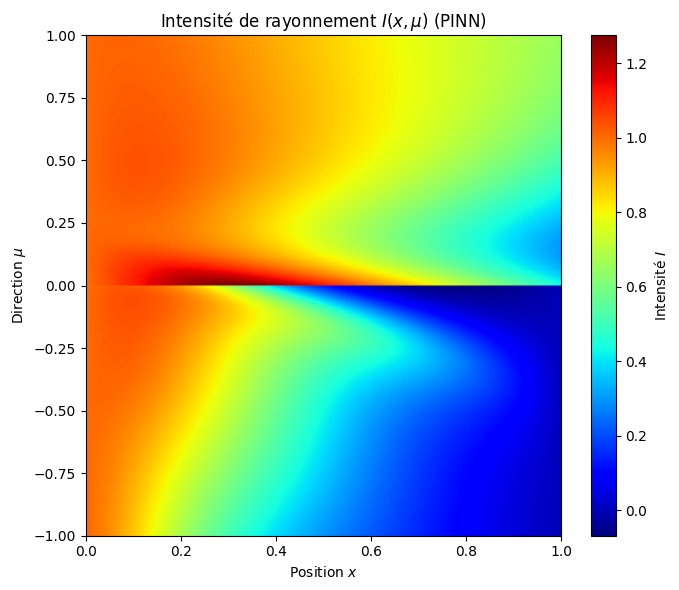

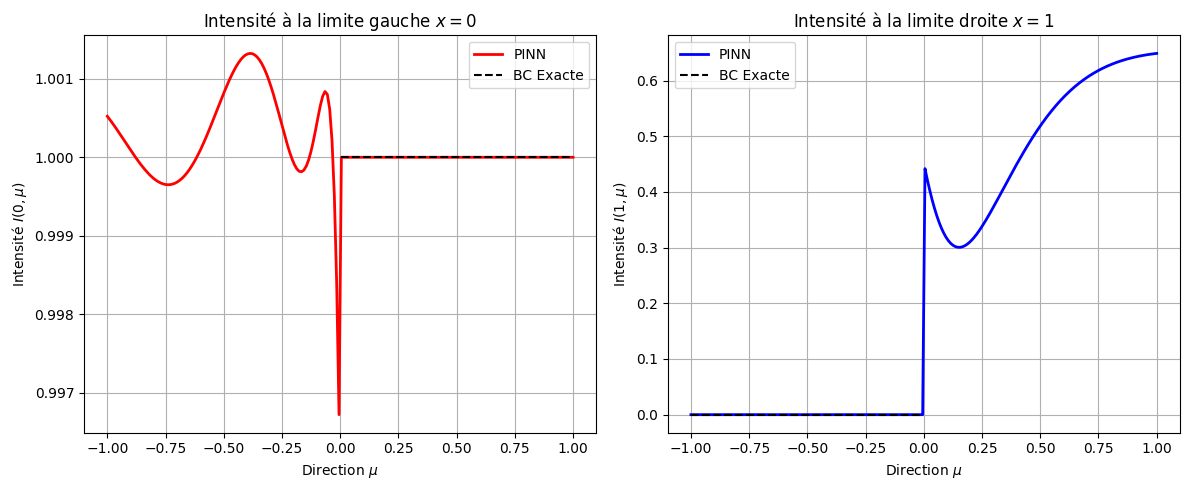

In [8]:

x_vals = np.linspace(0.0, 1.0, 200)
mu_vals = np.linspace(-1.0, 1.0, 200)
X, MU = np.meshgrid(x_vals, mu_vals)


grid_inputs = torch.tensor(np.stack([X.ravel(), MU.ravel()], axis=1), dtype=torch.float32).to(device)
with torch.no_grad():
    I_pred = modele(grid_inputs).cpu().numpy().reshape(X.shape)


fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(I_pred, cmap='jet', aspect='auto', origin='lower',
               extent=[0.0, 1.0, -1.0, 1.0])
ax.set_title("Intensité de rayonnement $I(x, \\mu)$ (PINN)")
ax.set_xlabel("Position $x$")
ax.set_ylabel("Direction $\\mu$")
fig.colorbar(im, label="Intensité $I$")
plt.tight_layout()
fig.savefig("intensity_heatmap.png", dpi=150)
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# À x = 0
inputs_x0 = torch.tensor(np.stack([np.zeros_like(mu_vals), mu_vals], axis=1), dtype=torch.float32).to(device)
with torch.no_grad():
    I_x0 = modele(inputs_x0).cpu().numpy().flatten()
axes[0].plot(mu_vals, I_x0, label="PINN", color="red", linewidth=2)
axes[0].plot(mu_vals[mu_vals > 0], np.ones_like(mu_vals[mu_vals > 0]), color="black", linestyle="--", label="BC Exacte")
axes[0].set_title("Intensité à la limite gauche $x = 0$")
axes[0].set_xlabel("Direction $\\mu$")
axes[0].set_ylabel("Intensité $I(0, \\mu)$")
axes[0].grid(True)
axes[0].legend()

# À x = 1
inputs_x1 = torch.tensor(np.stack([np.ones_like(mu_vals), mu_vals], axis=1), dtype=torch.float32).to(device)
with torch.no_grad():
    I_x1 = modele(inputs_x1).cpu().numpy().flatten()
axes[1].plot(mu_vals, I_x1, label="PINN", color="blue", linewidth=2)

axes[1].plot(mu_vals[mu_vals < 0], np.zeros_like(mu_vals[mu_vals < 0]), color="black", linestyle="--", label="BC Exacte")
axes[1].set_title("Intensité à la limite droite $x = 1$")
axes[1].set_xlabel("Direction $\\mu$")
axes[1].set_ylabel("Intensité $I(1, \\mu)$")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
fig.savefig("intensity_boundaries.png", dpi=150)
plt.show()
